# Does the estimate hold together across aggregation scales?

The correction forms a factor $P/R$ per reporting unit, applies it to that unit's raw total, and
sums. One could also form the factor higher up, over a region or over the whole country, by
averaging the drawn per-unit $P$ and $R$ weighted by raw detected capacity.

This notebook checks that the three routes give compatible national totals, and quantifies the
residual gap. **Only installed capacity is treated**, the quantity the paper audits.

## Why there is a gap, and what its sign must be

The unit-level total is $\sum_d C_d\,P_d/R_d = \big(\sum_d C_d\big)\,\bar f$, where $\bar f$ is the
mean **of the ratios**, weighted by raw capacity. The pooled total is $\big(\sum_d C_d\big)\,F$ with
$F = \bar P / \bar R$, the **ratio of the means**. The entire gap is that swap.

The numerator is harmless: it is linear, so averaging the $P$ before dividing costs nothing. The
denominator is what bites, because $1/R$ is convex. Hence an exact result:

> **If every $R_d$ in the group is equal, then $\bar f = F$ exactly, whatever the dispersion of the
> $P_d$.**

Pooling therefore costs nothing when recall is homogeneous, and costs more the more heterogeneous it
is. To second order:

$$\frac{F}{\bar f} - 1 \;\approx\; -\Big[\mathrm{CV}(R)^2 \;-\; \rho\,\mathrm{CV}(P)\,\mathrm{CV}(R)\Big]$$

The sign always runs against the pooled factor, unless $P$ and $R$ correlate strongly and
positively, which offsets part of it.

**A wording trap worth avoiding.** Recall is not underestimated. $\bar R$ is an honest weighted
mean. It is $1/\bar R$ that underestimates $\overline{1/R}$, and therefore the correction factor,
and therefore the corrected capacity. Saying "pooling underestimates recall" would be false and
would send a reader looking for a bug that is not there.

## Prior

Everything is computed with the empirical-Bayes prior carried by the alpha and beta columns of the
scores table, the one the correction consumes and which produces the paper's numbers. A Jeffreys
sensitivity closes the notebook.

**A historical note, kept because it explains a discrepancy someone may still find.** An earlier
version of this comparison, in the postprocess visualisation notebook, rebuilt the Beta parameters
by hand under Jeffreys while the pipeline had already moved to empirical Bayes. Its totals therefore
matched no published figure, and the 1.9% gap it displayed was a prior effect, not an aggregation
effect. This notebook replaces it.

## 0. Config

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _find_root(start, marker='paths.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(marker)


ROOT = _find_root(Path.cwd())
sys.path.insert(0, str(ROOT))
import paths
sys.path.insert(0, str(ROOT / 'code' / '0_pipeline' / 'postprocess' / 'recalibration'))
sys.path.insert(0, str(ROOT / 'code' / '0_pipeline' / 'evaluation' / 'src'))
import bootstrap
import helpers
import style
style.apply(fig_width_in=11)  # fonts scaled to the canvas width

FIGS_DIR = paths.FIGURES
FIG_PREFIX = 'sanity_scales'
N_BOOT = 10_000
SEED = 42

calib = pd.read_csv(paths.EVAL_TABLE, dtype={'dpt': str})
recal = gpd.read_file(
    paths.RECALIBRATION,
    ignore_geometry=True)

# The prior is read off the columns rather than assumed
_pa = (calib['alpha_precision'] - calib['tp_precision']).round(3).unique()
_ra = (calib['alpha_recall'] - calib['tp_recall']).round(3).unique()
assert len(_pa) == 1 and len(_ra) == 1, 'the prior is not constant across units'
print(f"prior empirical Bayes : precision Beta({_pa[0]}, ...), recall Beta({_ra[0]}, ...)")

PUBLISHED_P = recal['p_inst_mean'].sum()
print(f"published capacity (sum of per-unit means): {PUBLISHED_P:,.0f} kWp")

REGIONS = {
    'Auvergne-Rhone-Alpes': ['01', '03', '07', '15', '26', '38', '42', '43', '63', '69', '73', '74'],
    'Bourgogne-Franche-Comte': ['21', '25', '39', '58', '70', '71', '89', '90'],
    'Bretagne': ['22', '29', '35', '56'],
    'Centre-Val de Loire': ['18', '28', '36', '37', '41', '45'],
    'Corse': ['2A', '2B'],
    'Grand Est': ['08', '10', '51', '52', '54', '55', '57', '67', '68', '88'],
    'Hauts-de-France': ['02', '59', '60', '62', '80'],
    'Ile-de-France': ['75PC', '77', '78', '91', '95'],
    'Normandie': ['14', '27', '50', '61', '76'],
    'Nouvelle-Aquitaine': ['16', '17', '19', '23', '24', '33', '40', '47', '64', '79', '86', '87'],
    'Occitanie': ['09', '11', '12', '30', '31', '32', '34', '46', '48', '65', '66', '81', '82'],
    'Pays de la Loire': ['44', '49', '53', '72', '85'],
    "Provence-Alpes-Cote d'Azur": ['04', '05', '06', '13', '83', '84'],
}
_u2r = {u: r for r, us in REGIONS.items() for u in us}
recal['region'] = recal['dpt'].map(_u2r)
assert recal['region'].notna().all(), 'a unit has no region'
print(f"{len(REGIONS)} regions, {len(recal)} reporting units")

prior empirical Bayes : precision Beta(5.589, ...), recall Beta(16.029, ...)
published capacity (sum of per-unit means): 4,033,003 kWp
13 regions, 93 reporting units


## 1. The three levels

One estimator, three levels at which the factor is formed.

**Unit**: one factor per unit, applied to its raw capacity, then the draws summed term by term. This
is the reference, the route the correction script takes. It must reproduce the published figure to
machine precision, since expectation is linear.

**Region**: one factor per region, a weighted mean of the drawn per-unit rates, applied to the
regional raw capacity, then summed over the 13 regions.

**National**: a single factor, same construction, applied to the national raw capacity.

In [2]:
def _beta_params(df, prior):
    """Per-unit Beta parameters. `eb` reads them from the scores table, which is the
    pipeline's prior; `jeffreys` rebuilds them from the raw counts."""
    if prior == 'eb':
        return (df['alpha_precision'].to_numpy(), df['beta_precision'].to_numpy(),
                df['alpha_recall'].to_numpy(), df['beta_recall'].to_numpy())
    return (bootstrap.ALPHA_PRIOR + df['tp_precision'].to_numpy(),
            bootstrap.BETA_PRIOR + df['fp_precision'].to_numpy(),
            bootstrap.ALPHA_PRIOR + df['tp_recall'].to_numpy(),
            bootstrap.BETA_PRIOR + df['fn_recall'].to_numpy())


def _prepare(prior):
    cols = (['alpha_precision', 'beta_precision', 'alpha_recall', 'beta_recall'] if prior == 'eb'
            else ['tp_precision', 'fp_precision', 'tp_recall', 'fn_recall'])
    d = recal.merge(calib[['dpt', *cols]], on='dpt', how='left')
    return d.dropna(subset=[*cols, 'p_inst_raw']).reset_index(drop=True)


def draws_by_level(prior):
    """Draws of the corrected national capacity, at all three aggregation levels."""
    d = _prepare(prior)
    ap, bp, ar, br = _beta_params(d, prior)
    out = {}

    unit = np.zeros(N_BOOT)
    for i, row in d.iterrows():
        res = bootstrap.bootstrap_recalibration(
            {'p_inst': row['p_inst_raw']}, ap[i], bp[i], ar[i], br[i],
            n_boot=N_BOOT, seed=SEED, key=row['dpt'], return_draws=True)
        unit += res['draws']['p_inst']
    out['unit'] = unit

    for level, groups in (('region', d['region']), ('national', None)):
        acc = np.zeros(N_BOOT)
        items = ([('FR', d.index)] if groups is None
                 else d.groupby(groups).groups.items())
        for gname, idx in items:
            idx = np.asarray(idx)
            w = d.loc[idx, 'p_inst_raw'].to_numpy()
            factor = bootstrap.weighted_national_factor(
                ap[idx], bp[idx], ar[idx], br[idx], w,
                n_boot=N_BOOT, seed=SEED, key=f'{gname}|{prior}')
            acc += w.sum() * factor
        out[level] = acc
    return d, out


d_eb, draws = draws_by_level('eb')
print(f"{len(d_eb)} units retained")

93 units retained


### 1.1 A regression test: does the unit level reproduce the published figure?

$E[\sum_d X_d] = \sum_d E[X_d]$ holds whatever the dependence between the terms. A gap here would
signal a disagreement about the prior, the seed or the perimeter, never a statistical property. That
is what makes this a usable test rather than a check of something already known.

In [3]:
gap = draws['unit'].mean() / PUBLISHED_P - 1
print(f"unit level: {draws['unit'].mean():,.0f} kWp vs {PUBLISHED_P:,.0f} published ({gap:+.4%})")
assert abs(gap) < 1e-6, 'the reference route does not reproduce the paper'
print('OK -- regression test on the correction pipeline.')

unit level: 4,033,003 kWp vs 4,033,003 published (+0.0000%)
OK -- regression test on the correction pipeline.


### 1.2 Table

In [4]:
LEVELS = [('unit', f'Unit ({len(d_eb)})'), ('region', f'Region ({len(REGIONS)})'),
          ('national', 'National (1)')]


def summarize(dr):
    ref = dr['unit'].mean()
    rows = []
    for key, label in LEVELS:
        s = bootstrap.summarize_draws(dr[key])
        rows.append({'level': label, 'mean_kWp': s['mean'],
                     'ci95_low': s['ci95_low'], 'ci95_high': s['ci95_high'],
                     'gap_vs_unit': s['mean'] / ref - 1})
    return pd.DataFrame(rows)


conv = summarize(draws)
conv.to_csv(paths.CONVERGENCE_SCALES, index=False)
print(conv.assign(
    mean_kWp=lambda t: t.mean_kWp.map('{:,.0f}'.format),
    ci95_low=lambda t: t.ci95_low.map('{:,.0f}'.format),
    ci95_high=lambda t: t.ci95_high.map('{:,.0f}'.format),
    gap_vs_unit=lambda t: t.gap_vs_unit.map('{:+.2%}'.format)).to_string(index=False))

half = (conv.ci95_high.iloc[0] - conv.ci95_low.iloc[0]) / 2 / conv.mean_kWp.iloc[0]
print(f"\nhalf-width of the 95% interval at unit level: +/-{half:.1%} "
      f"-- the gaps between levels are an order of magnitude below it")

       level  mean_kWp  ci95_low ci95_high gap_vs_unit
   Unit (93) 4,033,003 3,962,439 4,105,564      +0.00%
 Region (13) 3,980,005 3,915,074 4,044,839      -1.31%
National (1) 3,982,269 3,918,416 4,048,195      -1.26%

half-width of the 95% interval at unit level: +/-1.8% -- the gaps between levels are an order of magnitude below it


## 2. The mechanism, in numbers

Three checks on the convexity explanation, deliberately of different kinds, because one of them
alone would be easy to fit after the fact.

The first is analytic: on a two-unit example, dispersing precision alone produces **no** gap at all,
while dispersing recall alone produces a large one.

The second is the second-order formula, held against the gap measured nationally.

The third is cross-sectional: across the 13 regions, the pooling gap should correlate with
within-region dispersion of **recall**, and not with that of precision. A theory that survives a
prediction about which of two variables matters is worth more than one that fits a single number.

In [5]:
# (i) two-unit example, equal weights
print("two-unit example, equal weights")
for lab, (P, R) in {'recall dispersed   ': (np.array([.9, .6]), np.array([.9, .3])),
                    'precision dispersed': (np.array([.9, .6]), np.array([.6, .6]))}.items():
    wn = np.array([.5, .5])
    fbar, F = (wn * (P / R)).sum(), (wn * P).sum() / (wn * R).sum()
    print(f"  {lab} : mean of ratios {fbar:.3f} | pooled {F:.3f} | gap {F / fbar - 1:+.1%}")

# (ii) the second-order formula, nationally
d_eb['P'] = d_eb.alpha_precision / (d_eb.alpha_precision + d_eb.beta_precision)
d_eb['R'] = d_eb.alpha_recall / (d_eb.alpha_recall + d_eb.beta_recall)
w = d_eb.p_inst_raw.to_numpy()
wn = w / w.sum()
mP, mR = (wn * d_eb.P).sum(), (wn * d_eb.R).sum()
cvP = np.sqrt((wn * (d_eb.P - mP) ** 2).sum()) / mP
cvR = np.sqrt((wn * (d_eb.R - mR) ** 2).sum()) / mR
rho = np.corrcoef(d_eb.P, d_eb.R)[0, 1]
fbar_nat = (wn * (d_eb.P / d_eb.R)).sum()
F_nat = mP / mR

print(f"\nnational : CV(P) = {cvP:.3f} | CV(R) = {cvR:.3f} | corr(P, R) = {rho:+.2f}")
print(f"  gap measured on the posterior means : {F_nat / fbar_nat - 1:+.2%}")
print(f"  formula, CV(R)^2 alone              : {-cvR ** 2:+.2%}")
print(f"  formula, CV(R)^2 - rho CV(P) CV(R)  : {-(cvR ** 2 - rho * cvP * cvR):+.2%}")

# (iii) 13 regions: within-group dispersion
rows = []
for reg, g in d_eb.groupby('region'):
    wg = g.p_inst_raw.to_numpy()
    wgn = wg / wg.sum()
    sd = lambda x: np.sqrt((wgn * (x - (wgn * x).sum()) ** 2).sum())
    rows.append({'region': reg,
                 'gap': (wgn * g.P).sum() / (wgn * g.R).sum() / (wgn * (g.P / g.R)).sum() - 1,
                 'sd_recall': sd(g.R.to_numpy()), 'sd_precision': sd(g.P.to_numpy())})
reg_disp = pd.DataFrame(rows)
reg_disp.to_csv(paths.CONVERGENCE_REGIONS, index=False)
rho_R = reg_disp.sd_recall.corr(reg_disp.gap.abs(), method='spearman')
rho_P = reg_disp.sd_precision.corr(reg_disp.gap.abs(), method='spearman')
print(f"\n13 regions -- Spearman |gap| against recall dispersion    : {rho_R:+.2f}")
print(f"              Spearman |gap| against precision dispersion : {rho_P:+.2f}")

two-unit example, equal weights
  recall dispersed    : mean of ratios 1.500 | pooled 1.250 | gap -16.7%
  precision dispersed : mean of ratios 1.250 | pooled 1.250 | gap +0.0%

national : CV(P) = 0.149 | CV(R) = 0.143 | corr(P, R) = +0.55
  gap measured on the posterior means : -0.77%
  formula, CV(R)^2 alone              : -2.03%
  formula, CV(R)^2 - rho CV(P) CV(R)  : -0.86%

13 regions -- Spearman |gap| against recall dispersion    : +0.86
              Spearman |gap| against precision dispersion : -0.08


## 3. Figure

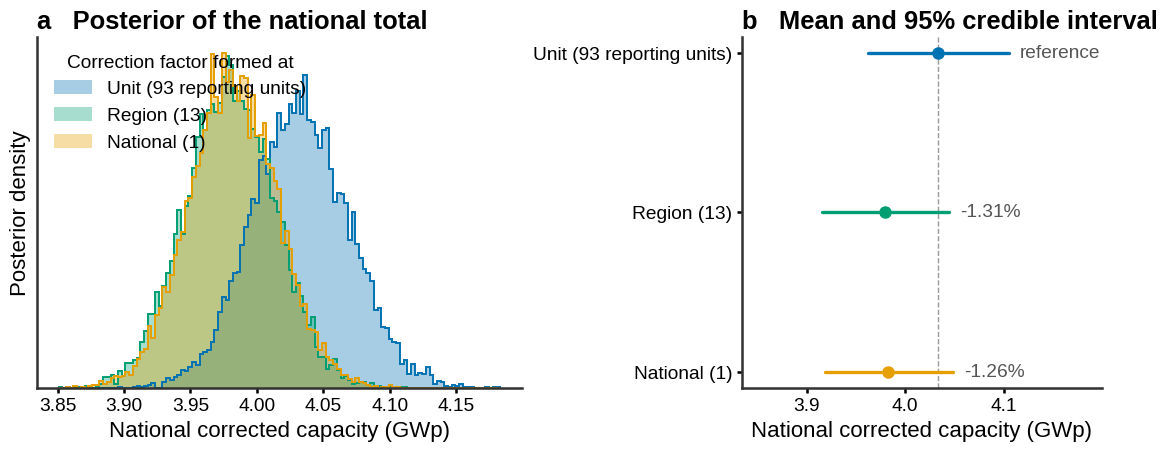

In [6]:
C = {'unit': style.OKABE_ITO['blue'],
     'region': style.OKABE_ITO['bluish_green'],
     'national': style.OKABE_ITO['orange']}
NAME = {'unit': f'Unit ({len(d_eb)} reporting units)',
        'region': f'Region ({len(REGIONS)})',
        'national': 'National (1)'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4), layout='constrained',
                               gridspec_kw={'width_ratios': [1.35, 1]})

# (a) the three posteriors, overlaid
lo = min(dr.min() for dr in draws.values())
hi = max(dr.max() for dr in draws.values())
bins = np.linspace(lo, hi, 120)
for key in ('unit', 'region', 'national'):
    ax1.hist(draws[key] / 1e6, bins=bins / 1e6, density=True, histtype='stepfilled',
             alpha=0.35, color=C[key], label=NAME[key])
    ax1.hist(draws[key] / 1e6, bins=bins / 1e6, density=True, histtype='step',
             lw=1.4, color=C[key])
ax1.set_xlabel('National corrected capacity (GWp)')
ax1.set_ylabel('Posterior density')
ax1.set_title('a   Posterior of the national total', fontweight='bold',
              fontsize=style.FONT_SIZE_PANEL_LABEL, loc='left')
ax1.legend(loc='upper left', fontsize=style.FONT_SIZE_SMALL, frameon=False,
           title='Correction factor formed at', title_fontsize=style.FONT_SIZE_SMALL)
ax1.set_yticks([])

# (b) means and 95% intervals
y = np.arange(len(LEVELS))[::-1]
for yi, (key, _) in zip(y, LEVELS):
    s = bootstrap.summarize_draws(draws[key])
    ax2.plot([s['ci95_low'] / 1e6, s['ci95_high'] / 1e6], [yi, yi], color=C[key], lw=2.4,
             solid_capstyle='round')
    ax2.plot(s['mean'] / 1e6, yi, 'o', ms=8, color=C[key], zorder=3)
    ax2.annotate(f"{conv.gap_vs_unit.iloc[list(y).index(yi)]:+.2%}"
                 if key != 'unit' else 'reference',
                 (s['ci95_high'] / 1e6, yi), xytext=(8, 0), textcoords='offset points',
                 va='center', fontsize=style.FONT_SIZE_SMALL, color='#555555')
ax2.axvline(PUBLISHED_P / 1e6, color='#999999', ls='--', lw=1.0, zorder=0)
ax2.set_yticks(y)
ax2.set_yticklabels([NAME[k] for k, _ in LEVELS])
ax2.set_xlabel('National corrected capacity (GWp)')
ax2.set_xlim(ax1.get_xlim())
ax2.set_title('b   Mean and 95% credible interval', fontweight='bold',
              fontsize=style.FONT_SIZE_PANEL_LABEL, loc='left')

helpers.save_fig(fig, f'{FIG_PREFIX}_aggregation_levels.png', FIGS_DIR)
plt.show()

## 4. Sensibilite au prior

In [7]:
_, draws_j = draws_by_level('jeffreys')
conv_j = summarize(draws_j)
print(pd.DataFrame({
    'level': conv['level'],
    'gap_EB': conv['gap_vs_unit'].map('{:+.2%}'.format),
    'gap_Jeffreys': conv_j['gap_vs_unit'].map('{:+.2%}'.format),
}).to_string(index=False))
print(f"\nunit level: empirical Bayes {draws['unit'].mean():,.0f} kWp | "
      f"Jeffreys {draws_j['unit'].mean():,.0f} kWp "
      f"({draws_j['unit'].mean() / draws['unit'].mean() - 1:+.2%})")
print("Jeffreys pulls the estimate upward, so the informative prior retained is the more")
print("conservative of the two with respect to the under-reporting claim.")

       level gap_EB gap_Jeffreys
   Unit (93) +0.00%       +0.00%
 Region (13) -1.31%       -2.15%
National (1) -1.26%       -2.35%

unit level: empirical Bayes 4,033,003 kWp | Jeffreys 4,110,686 kWp (+1.93%)
Jeffreys pulls the estimate upward, so the informative prior retained is the more
conservative of the two with respect to the under-reporting claim.


## 5. What this establishes

The unit level reproduces the published figure to machine precision, so this notebook doubles as a
regression test on the correction pipeline.

The three levels give national totals whose credible intervals overlap heavily. The largest gap
between levels is about 1%, against a credible half-width of roughly 2%: the difference of scale
sits below the sampling noise.

That does not make the gap noise. It is signed. Pooling always produces a smaller factor, and
therefore a lower corrected capacity, by convexity of $1/R$. Its size is governed by the dispersion
**of recall** inside the pooled group, with precision dispersion contributing nothing. The three
checks in section 2 confirm all of that, including the prediction about which variable matters.

The practical consequence is simple, and it is the reason the notebook exists: there is no
trade-off to arbitrate. Forming the factor at the finest level for which a calibration exists is
weakly better, always. The variance argument that would otherwise plead for pooling is already
handled elsewhere, by the empirical-Bayes prior, which shrinks thinly sampled units on $P$ and $R$
separately without forcing the ratio to be pooled.